# Description

https://zenodo.org/records/8099322\
https://zenodo.org/records/6366271\
https://zenodo.org/records/6366324

# ATLFast3 data

https://opendata-qa.cern.ch/record/15012

* $K$: number of events
    - dataset 1.photons:    242000
    - dataset 1.pions:      241600
    - dataset 2:            200000
    - dataset 3:            200000
* $V$: total number of voxels
    - dataset 1.photons:      368     (5 layers, inhomogeneous splits)
    - dataset 1.pions:        533     (7 layers, inhomogeneous splits)
    - **dataset 2:            6480    (45 layers, 16 ang splits, 9 rad splits)**
    - **dataset 3:            40500   (45 layers, 50 ang splits, 18 rad splits)**
* $E_{i}=1,\dots,K$: incident energy
* $\pmb{x}_{i}\in \mathbb{R}^V$ energy deposits across voxels
* `showers` numpy array of shape (K, V)
* `incident_energies` numpy array of shape (K, 1)

$$
\pmb{E} = 
\begin{bmatrix}
E_1\\
E_2\\
\vdots\\
E_K
\end{bmatrix},
\ \ \ 
X = 
\begin{bmatrix}
\ \pmb{x}^t_1 \\
\ \pmb{x}^t_2 \\
\vdots\\
\ \pmb{x}^t_K
\end{bmatrix}
$$

$$
\pmb{x}_i = f(E_i;\ pid_j,\ geometry_j),\quad i=1,..,K,\quad j={1,2,3,4}
$$

## Load dataset

In [1]:
!git clone https://github.com/OzAmram/CaloChallenge.git

fatal: destination path 'CaloChallenge' already exists and is not an empty directory.


In [2]:
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
import sys
sys.path.append('./CaloChallenge/code')
from HighLevelFeatures import HighLevelFeatures as HLF
import os
from utilities import CaloChallenge

# === Path to your dataset ===
filename = "../calo-data/dataset_2_2.hdf5"
binning_filename = './CaloChallenge/code/binning_dataset_2.xml'

# filename = "/home/pgeorgantopoulos/cern/GEANT4/CaloChallengeCyl-build/showers.hdf5"
# binning_filename = '/home/pgeorgantopoulos/cern/GEANT4/CaloChallengeCyl-build/binning.xml'

i_idcs = None
# i_idcs = np.arange(0, 100)

hlf_ds = HLF('electron', filename=binning_filename)

ds                = CaloChallenge(filename, hlf_ds, i_idcs=i_idcs)
showers           = ds.showers
incident_energies = ds.energies

Features in dataset_2_2.hdf5: ['incident_energies', 'showers']
Showers shape: (100000, 6480)
Incident energies shape: (100000, 1)
showers_4d shape: (100000, 9, 16, 45)


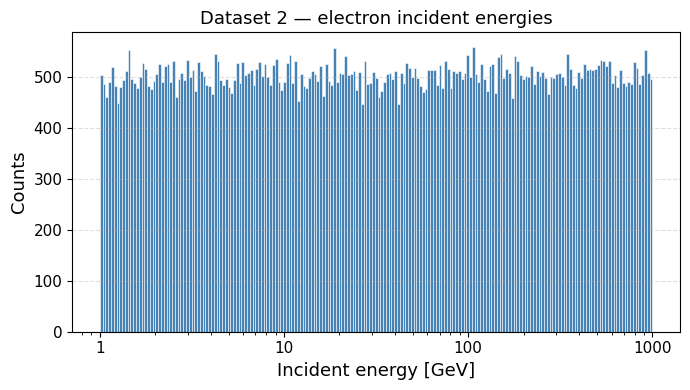

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

energies_gev = incident_energies / 1e3  # MeV → GeV
bins = np.geomspace(energies_gev.min(), energies_gev.max(), 200)

ax.hist(energies_gev, bins=bins, color="steelblue", edgecolor="white", linewidth=0.4)
ax.set_xscale("log")
ax.set_xlabel("Incident energy [GeV]", fontsize=13)
ax.set_ylabel("Counts", fontsize=13)
ax.set_title("Dataset 2 — electron incident energies", fontsize=13)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:g}"))
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.tick_params(labelsize=11)
fig.tight_layout()
plt.show()

## Layer profiles of a single shower

In [4]:
# from utilities import plot_single_shower_layers

# i_idx = 0
# hlf   = HLF('photon', filename='./CaloChallenge/code/binning_dataset_1_photon.xml')
# plot_single_shower_layers(showers, hlf, i_idx=i_idx)

## Average shower for Energy Level

In [5]:
# from utilities import plot_average_shower

# plot_average_shower(showers, incident_energies, hlf)

In [6]:
from utilities import plot_shower_3d

i_idx     = 1
threshold = 1  # MeV

shower3d = showers[i_idx, :, :, :]
plot_shower_3d(shower3d, i_idx=i_idx, incident_energy=incident_energies.flatten()[i_idx], threshold=threshold)

## Video: shower profile across layers

In [7]:
from utilities import make_shower_layer_video
from IPython.display import Video

i_idx = 1
video_path = make_shower_layer_video(
    showers[i_idx],
    i_idx=i_idx,
    incident_energy=incident_energies.flatten()[i_idx],
    out_path="shower_layers.mp4",
    seconds_per_layer=1.0,
)
Video(video_path, embed=True)

(<Figure size 2000x600 with 2 Axes>,
 array([<Axes: title={'center': 'MeV'}>,
        <Axes: title={'center': 'log(MeV)'}>], dtype=object))

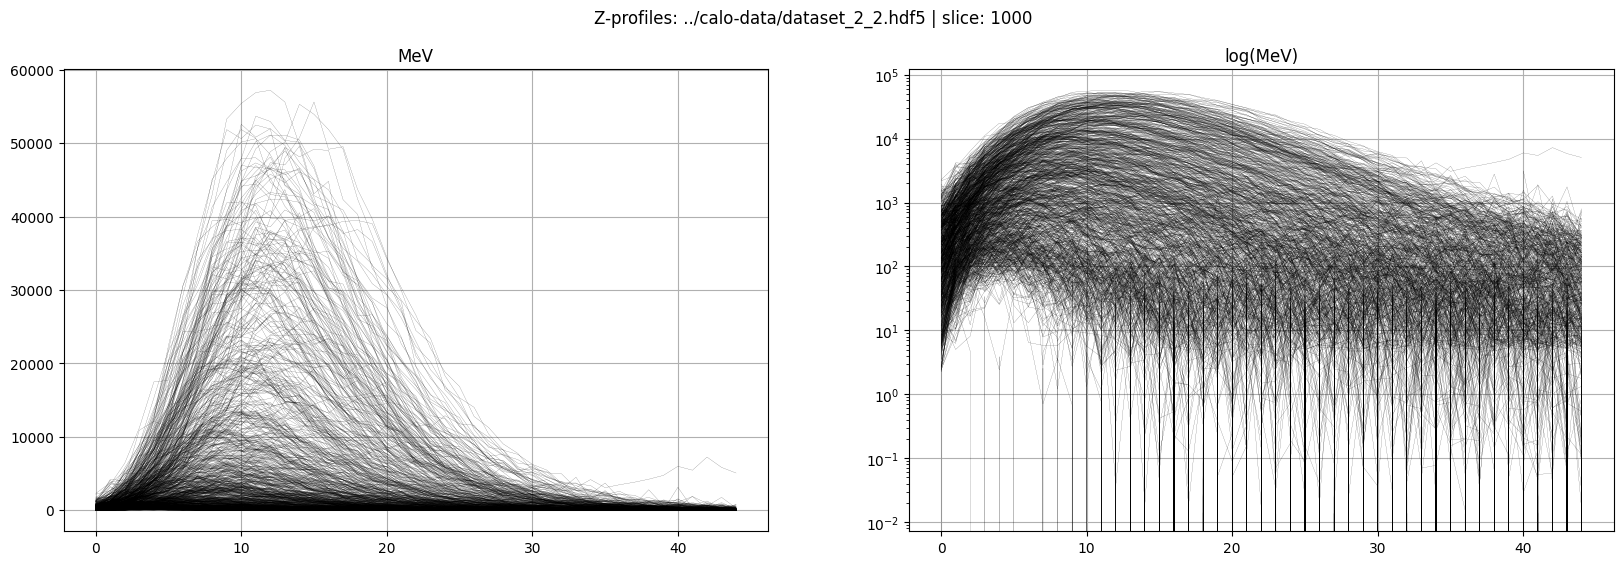

In [8]:
from utilities import plot_z_profiles
i_idcs = 1000
plot_z_profiles(showers, filename=filename, i_idcs=i_idcs)

## Comparison Plots: Energy Distribution + Radial Profile

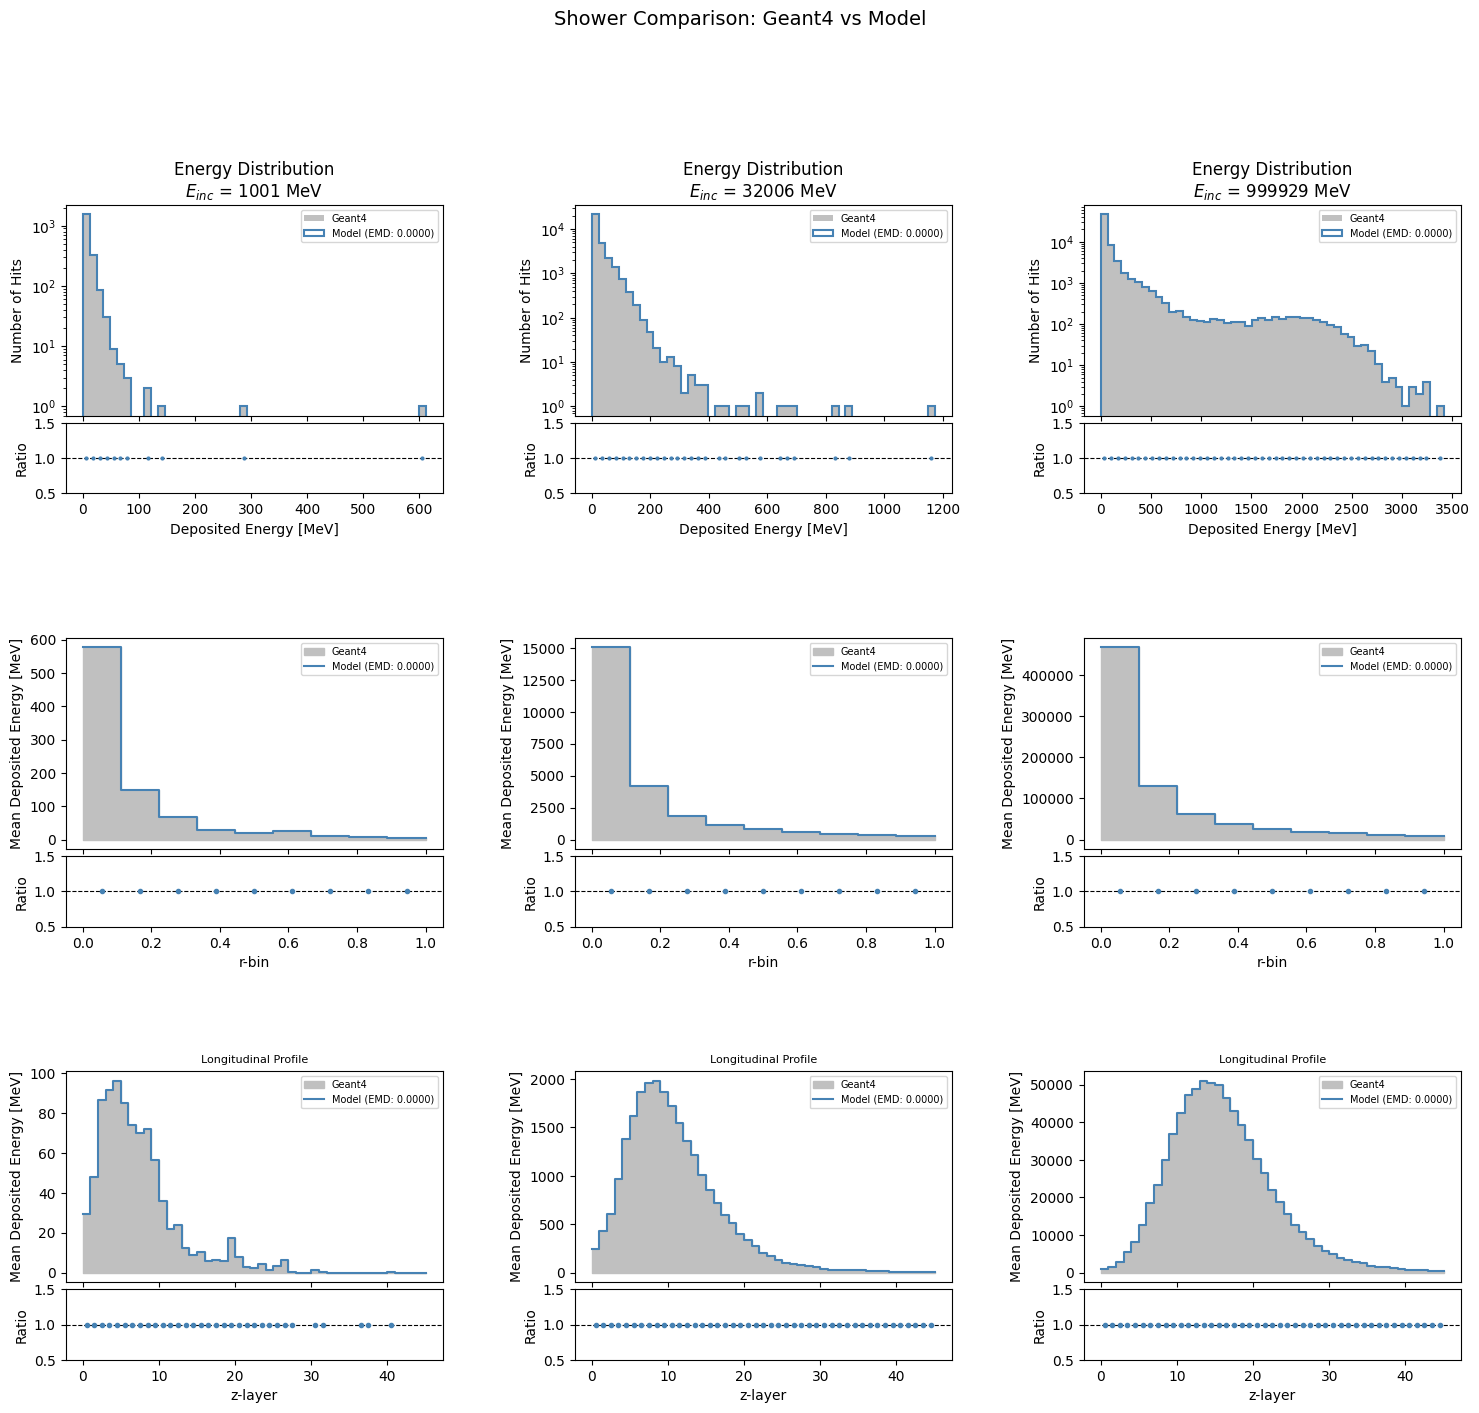

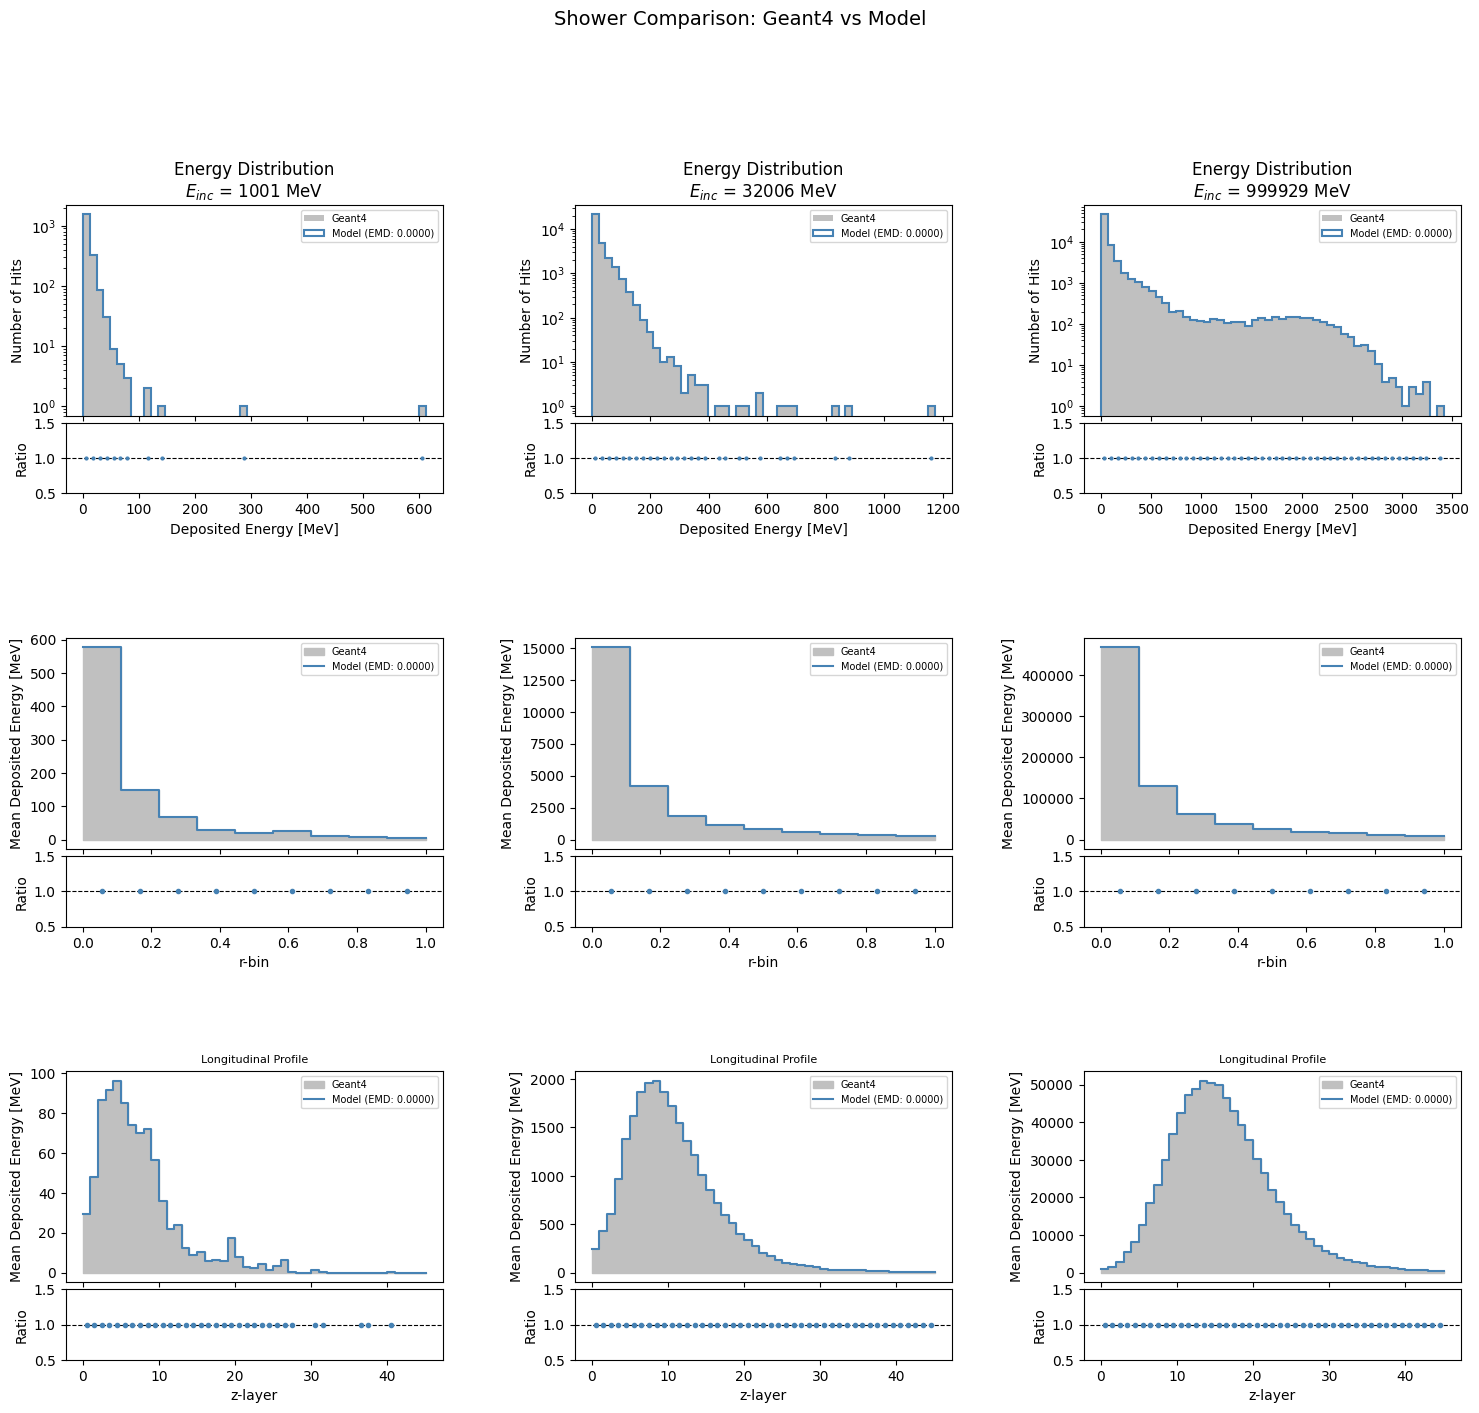

In [9]:
from utilities import plot_comparison

# Replace gen_showers / gen_energies with your model's output.
# Your model must produce showers in (K, R, PHI, Z) = (K, 9, 16, 45) format.
ref_showers_c  = showers
ref_energies_c = incident_energies

gen_showers_c  = showers           # ← replace with your model output
gen_energies_c = incident_energies # ← replace with generated energies
gen_label      = "Model"           # ← replace with your model name

plot_comparison(ref_showers_c, ref_energies_c, gen_showers_c, gen_energies_c, gen_label=gen_label)